In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler,LabelEncoder

In [9]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data"
columns = ['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
              'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color','stalk-shape']

In [10]:
df = pd.read_csv(url, header=None, names=columns)
df.head()

class cap-shape cap-surface cap-color bruises odor  \
p x s n t p f c n k e e     s         s           w         w       p    w   
e x s y t a f c b k e c     s         s           w         w       p    w   
  b s w t l f c b n e c     s         s           w         w       p    w   
p x y w t p f c n n e e     s         s           w         w       p    w   
e x s g f n f w b k t e     s         s           w         w       p    w   

                        gill-attachment gill-spacing gill-size gill-color  \
p x s n t p f c n k e e               o            p         k          s   
e x s y t a f c b k e c               o            p         n          n   
  b s w t l f c b n e c               o            p         n          n   
p x y w t p f c n n e e               o            p         k          s   
e x s g f n f w b k t e               o            e         n          a   

                        stalk-shape  
p x s n t p f c n k e e           u  
e x s y t a f c b k e c           g  
  b s w t l f c b n e c           m  
p x y w t p f c n n e e           u  
e x s g f n f w b k t e           g

In [11]:
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

In [12]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('class', axis=1), df['class'], test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = SVC(kernel='linear', random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("\n----Final Test Report----")

print(classification_report(y_test, y_pred))


----Final Test Report----
              precision    recall  f1-score   support

           0       0.29      0.11      0.16       109
           1       0.77      0.72      0.74       455
           2       0.81      0.88      0.85      1057
           3       1.00      1.00      1.00         4

    accuracy                           0.79      1625
   macro avg       0.72      0.68      0.69      1625
weighted avg       0.76      0.79      0.77      1625



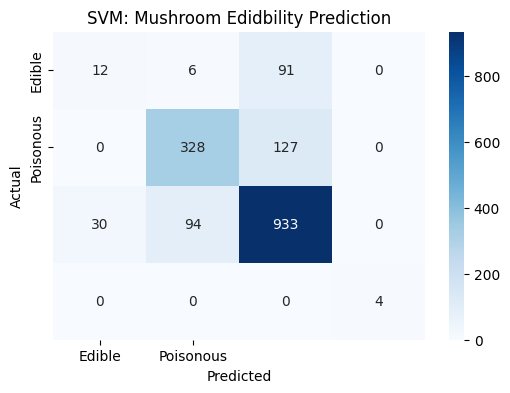

In [14]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'])
plt.title('SVM: Mushroom Edidbility Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
